# OlmoEarth + DHS geo-displacement: what the fuzzy coordinates cost, and what to do about it

*A companion to the areal-prediction spike (`FEASIBILITY.md`). It tackles the
real obstacle to using OlmoEarth embeddings with **DHS** data: the coordinates
are deliberately imprecise.*

**The confidentiality mechanism.** DHS randomly displaces each cluster's GPS
([Burgert et al. 2013](https://dhsprogram.com/pubs/pdf/SAR7/SAR7.pdf)):
**urban 0–2 km, rural 0–5 km, and 1% of rural clusters up to 10 km**, random
direction, distance uniform in [0, max], kept inside the cluster's admin-2 unit.
So the outcome is attached to a location that could be anywhere in a disc of
radius 2–10 km. If you read an embedding at the published point, you often sample
the **wrong** landscape — attenuating the embedding→outcome signal before any
model sees it.

**Is layering an autoencoder on OlmoEarth "fine-tuning"?** Only if OlmoEarth's own
weights move:
- **Frozen backbone + a new module on top** (an autoencoder, an MLP head, a linear
  probe on the 768-dim embeddings) — **not** fine-tuning. You use OlmoEarth as a
  fixed feature extractor and train only what you bolt on. Cheap, CPU-friendly,
  hard to overfit — extract embeddings **once** and reuse.
- **Unfreezing and updating OlmoEarth** — fine-tuning proper. Powerful, but needs a
  GPU and lots of labels, and risks overfitting to a **fuzzy-located** target.
- **PEFT (LoRA/adapters)** — small trainable modules in a frozen backbone, trained
  with the backbone in the loop. A lightweight *form of* fine-tuning; still needs
  backprop through OlmoEarth.

A plain autoencoder optimizes *reconstruction*, not prediction, so it needn't
capture DHS-relevant structure. The task-aligned cousins do: a **supervised
bottleneck** (`embedding → bottleneck → outcome`) and a **semi-supervised
autoencoder** (reconstruct on the whole unlabeled map **+** predict on the few
labeled clusters). This notebook demonstrates the prerequisite any of these
builds on — **recovering signal despite displacement** — and measures a
supervised bottleneck against a plain linear head.

> ### ⚠️ What is real here
> - The Sentinel-2 **landscape is real**; embeddings run on real pixels.
> - The survey **clusters and outcome are synthetic**. The outcome is a latent
>   landscape factor the embedding captures *by construction* (top PC of the local
>   embedding) — chosen so we isolate the **displacement** effect, not "how well
>   does OlmoEarth encode NDVI." It is **not** a real DHS indicator.
> - Goal: a reusable **method + honest expectations** a student can apply to real
>   (restricted) DHS data — not an epidemiological result.


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score

from olmoearth_pretrain_minimal import ModelID
from olmoe import load_encoder
from movement import load_landscape, ndvi_map
import dhs

# --- config ---
VARIANT = "TINY"            # fast + re-runnable; BASE is the production choice
AOI     = (35.38, -14.83)   # Liwonde NP, Malawi
SIZE_PX = 768               # 7.68 km window @10 m
STEP    = 24                # embedding-grid spacing (240 m)
N_CLUST = 250               # synthetic survey clusters
BOX_PX  = 130               # clusters in a central box (leaves room to displace)
REGIMES = [0.0, 0.5, 1.0, 1.5, 2.0]   # displacement max (km)
DRAWS   = 5                 # displacement realizations averaged per regime
NOISE   = 0.25              # outcome noise sd

if "HTTPS_PROXY" in os.environ:      # COG reads via GDAL/curl behind the proxy
    os.environ.setdefault("GDAL_HTTP_PROXY", os.environ["HTTPS_PROXY"])
    os.environ.setdefault("CURL_CA_BUNDLE", "/root/.ccr/ca-bundle.crt")

def ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 20)))
def cv_r2(X, y):
    return r2_score(y, cross_val_predict(ridge(), X, y, cv=KFold(5, shuffle=True, random_state=0)))
print("variant:", VARIANT)

/home/user/ai_assisted_research/olmoearth_spike/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


variant: TINY


## Step 1 — a real landscape and its embedding grid

Load one Sentinel-2 window, embed a dense grid of chips **once** (so every
displacement experiment below is a cheap lookup), and define the latent outcome
factor from those embeddings.

scene S2B_36LYJ_20210702_1_L2A | grid (30, 30, 192) embedded in 27s


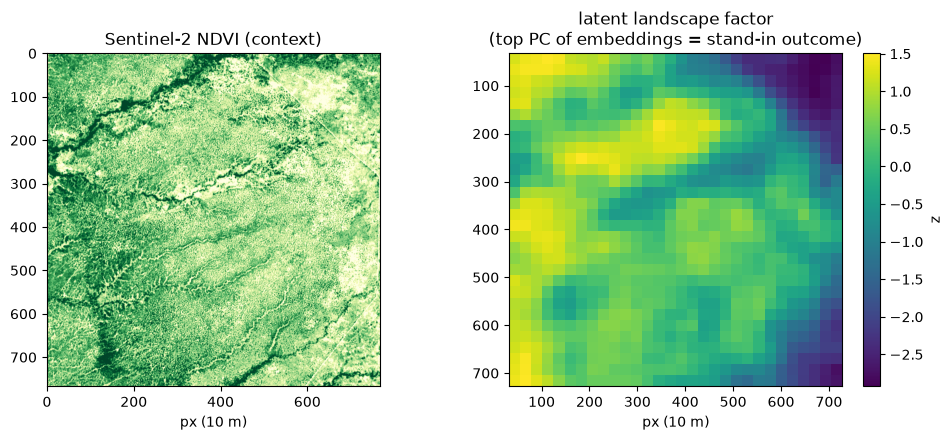

In [2]:
stack, meta = load_landscape(*AOI, size_px=SIZE_PX, n_dates=3)
ndvi = ndvi_map(stack)
model = load_encoder(getattr(ModelID, f"OLMOEARTH_V1_{VARIANT}"))
t0 = time.perf_counter()
E, rows, cols = dhs.embedding_grid(model, stack, meta["months"], step=STEP)
field = dhs.latent_factor(E)     # (n_rows, n_cols) standardized latent factor
print(f"scene {meta['scene']} | grid {E.shape} embedded in {time.perf_counter()-t0:.0f}s")

fig, axs = plt.subplots(1, 2, figsize=(10, 4.4))
axs[0].imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
axs[0].set_title("Sentinel-2 NDVI (context)")
im = axs[1].imshow(field, extent=[cols[0], cols[-1], rows[-1], rows[0]], cmap="viridis")
axs[1].set_title("latent landscape factor\n(top PC of embeddings = stand-in outcome)")
for a in axs: a.set_xlabel("px (10 m)")
fig.colorbar(im, ax=axs[1], fraction=0.046, label="z"); plt.tight_layout(); plt.show()

## Step 2 — synthetic clusters and DHS-style displacement

Place clusters at **true** locations, read their outcome from the latent factor,
then displace each coordinate as DHS does (random angle, distance uniform in
[0, max]).

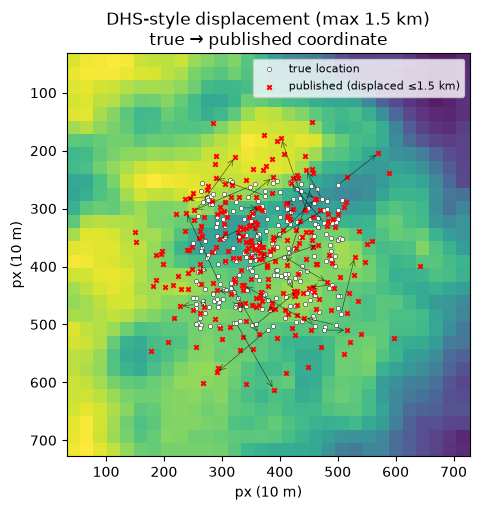

In [3]:
clusters = dhs.make_clusters(rows, cols, n=N_CLUST, box_px=BOX_PX, seed=1)
y_true = dhs.sample_field(field, rows, cols, clusters, noise_sd=NOISE, seed=2)

demo_km = 1.5
disp = dhs.displace(clusters, demo_km, seed=3)
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.imshow(field, extent=[cols[0], cols[-1], rows[-1], rows[0]], cmap="viridis", alpha=0.9)
sub = slice(0, None, 6)   # show a subset of arrows for legibility
ax.scatter(clusters[:,1], clusters[:,0], s=10, c="white", edgecolor="k", linewidth=0.3, label="true location")
ax.scatter(disp[:,1], disp[:,0], s=10, c="red", marker="x", label=f"published (displaced ≤{demo_km} km)")
for (r,c),(dr,dc) in zip(clusters[sub], disp[sub]):
    ax.annotate("", xy=(dc,dr), xytext=(c,r), arrowprops=dict(arrowstyle="->", color="k", lw=0.5, alpha=0.6))
ax.set_title(f"DHS-style displacement (max {demo_km} km)\ntrue → published coordinate")
ax.legend(loc="upper right", fontsize=8); ax.set_xlabel("px (10 m)"); ax.set_ylabel("px (10 m)")
plt.tight_layout(); plt.show()

## Step 3 — the experiment: point embedding vs. displacement-matched buffer

For each displacement max we compare two covariates, averaged over several
displacement draws:
- **point** — the embedding at the (displaced) published coordinate;
- **buffer** — the mean embedding over a disc of radius = displacement max around
  the published point. The disc is **guaranteed to contain the true location**.

The dashed **oracle** line is the point embedding at the *true* location — the
ceiling if there were no displacement.

 0.0 km  point R²=+0.760  buffer R²=+0.671


 0.5 km  point R²=+0.410  buffer R²=+0.398


 1.0 km  point R²=+0.153  buffer R²=+0.149


 1.5 km  point R²=+0.054  buffer R²=+0.086


 2.0 km  point R²=+0.012  buffer R²=+0.040


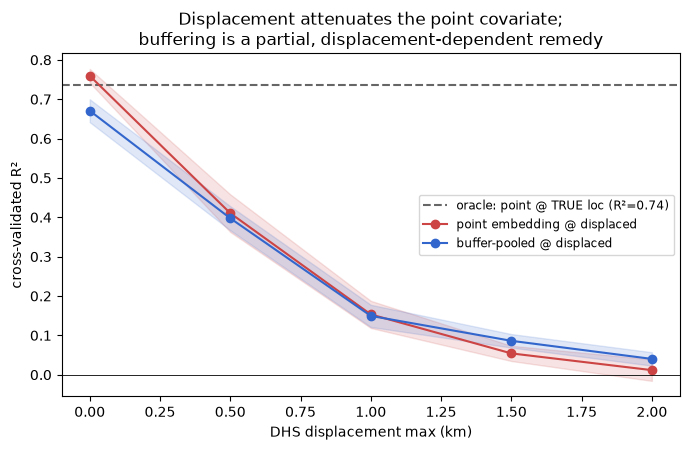

In [4]:
oracle = cv_r2(dhs.point_features(clusters, E, rows, cols), y_true)

pt_mean, pt_sd, bf_mean, bf_sd = [], [], [], []
for km in REGIMES:
    pts_r2, buf_r2 = [], []
    for s in range(DRAWS):
        y = dhs.sample_field(field, rows, cols, clusters, noise_sd=NOISE, seed=100+s)
        dp = dhs.displace(clusters, km, seed=200+s)
        pts_r2.append(cv_r2(dhs.point_features(dp, E, rows, cols), y))
        buf_r2.append(cv_r2(dhs.buffer_features(dp, E, rows, cols, km*dhs.PX_PER_KM + STEP), y))
    pt_mean.append(np.mean(pts_r2)); pt_sd.append(np.std(pts_r2))
    bf_mean.append(np.mean(buf_r2)); bf_sd.append(np.std(buf_r2))
    print(f"{km:4.1f} km  point R²={np.mean(pts_r2):+.3f}  buffer R²={np.mean(buf_r2):+.3f}")
pt_mean, pt_sd = np.array(pt_mean), np.array(pt_sd)
bf_mean, bf_sd = np.array(bf_mean), np.array(bf_sd)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.axhline(oracle, ls="--", color="0.4", label=f"oracle: point @ TRUE loc (R²={oracle:.2f})")
ax.plot(REGIMES, pt_mean, "-o", color="#c44", label="point embedding @ displaced")
ax.fill_between(REGIMES, pt_mean-pt_sd, pt_mean+pt_sd, color="#c44", alpha=0.15)
ax.plot(REGIMES, bf_mean, "-o", color="#36c", label="buffer-pooled @ displaced")
ax.fill_between(REGIMES, bf_mean-bf_sd, bf_mean+bf_sd, color="#36c", alpha=0.15)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("DHS displacement max (km)"); ax.set_ylabel("cross-validated R²")
ax.set_title("Displacement attenuates the point covariate;\nbuffering is a partial, displacement-dependent remedy")
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()

## Step 4 — does a supervised bottleneck head help?

At a fixed displacement, compare a plain linear head (**ridge**) with a
**supervised-bottleneck MLP** (`768 → 64 → 8 → outcome`) on the buffer covariate.
With few clusters, the learned head has to earn its extra capacity.

ridge · point              R²=+0.075
ridge · buffer             R²=+0.109
bottleneck MLP · buffer    R²=-0.085


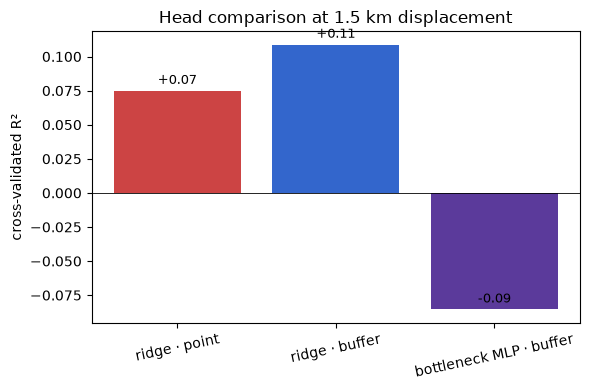

In [5]:
km = 1.5
y = dhs.sample_field(field, rows, cols, clusters, noise_sd=NOISE, seed=7)
dp = dhs.displace(clusters, km, seed=8)
Xp = dhs.point_features(dp, E, rows, cols)
Xb = dhs.buffer_features(dp, E, rows, cols, km*dhs.PX_PER_KM + STEP)
def mlp():
    return make_pipeline(StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 8), alpha=1e-2, max_iter=3000,
                     early_stopping=True, random_state=0))
def cv_r2_mlp(X, y):
    return r2_score(y, cross_val_predict(mlp(), X, y, cv=KFold(5, shuffle=True, random_state=0)))

res = {"ridge · point": cv_r2(Xp, y), "ridge · buffer": cv_r2(Xb, y),
       "bottleneck MLP · buffer": cv_r2_mlp(Xb, y)}
for k, v in res.items(): print(f"{k:26s} R²={v:+.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(res), list(res.values()), color=["#c44", "#36c", "#5B3A9B"])
ax.axhline(0, color="k", lw=0.6); ax.set_ylabel("cross-validated R²")
ax.set_title(f"Head comparison at {km} km displacement")
for i, v in enumerate(res.values()): ax.text(i, v+0.005, f"{v:+.2f}", ha="center", fontsize=9)
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

## What this means for using OlmoEarth with real DHS

**The displacement is the dominant design constraint, not the model.**
- The point covariate collapses as displacement grows (oracle ≈ 0.7 → near 0 by
  ~2 km). DHS's 2–5 km displacement will erode a naive point-embedding covariate.
- A displacement-matched **buffer** recovers only a little, and mostly once
  displacement exceeds the chip's own footprint. It **trades resolution for
  robustness** and itself fades as the buffer grows — so it is a mitigation, not a
  cure, and it will not rescue 5–10 km rural displacement on its own.
- A **supervised bottleneck** head is, at best, on par with ridge here — with few,
  fuzzy-located labels, a light regularized linear head is the sane default; a
  learned bottleneck earns its keep only with more data.

**The design menu (spend effort here, keep the backbone frozen):**
1. **Buffer / integrate over the displacement kernel.** Pool over the known
   displacement radius; the kernel is known (uniform-in-distance, bounded), so
   weight candidates — and down-weight non-settlement pixels, since clusters are
   inhabited (using imagery to partly *undo* the displacement).
2. **Multiple-instance learning.** Treat each cluster as a *bag* of candidate
   locations and learn a bag-level predictor.
3. **Aggregate to areal units.** Displacement stays **within admin-2**, so
   predicting at admin-1/2 (as the main spike does) averages the error out — the
   most robust option, and the one the funded project already needs.
4. **Semi-supervised autoencoder.** Reconstruct embeddings across the whole
   unlabeled map **+** predict DHS on the few labeled clusters, so the latent is
   regularized by abundant unlabeled data and steered toward the outcome.
5. **PEFT / fine-tuning last.** Only if frozen features plateau — the fuzzy label
   location caps its upside and it is the most expensive, most overfit-prone lever.

**Honest caveats.** Synthetic clusters and outcome; a single small window and one
variant (TINY here; BASE for production, though the mechanism is
variant-independent); the latent-factor target makes "the embedding encodes the
outcome" true by construction, which isolates displacement but flatters absolute
R². Swap in real DHS clusters + a real indicator and the *relative* comparison
(point vs. buffer vs. areal aggregation) is what transfers.

**References:**
[DHS displacement procedure (Burgert et al. 2013)](https://dhsprogram.com/pubs/pdf/SAR7/SAR7.pdf) ·
[Yeh et al. 2020, *Nature Comms* — CNN features + ridge for DHS wealth](https://www.nature.com/articles/s41467-020-16185-w) ·
[Jean et al. 2016, *Science* — transfer learning for poverty](https://www.science.org/doi/10.1126/science.aaf7894)

saved outputs/dhs_displacement_figure.png


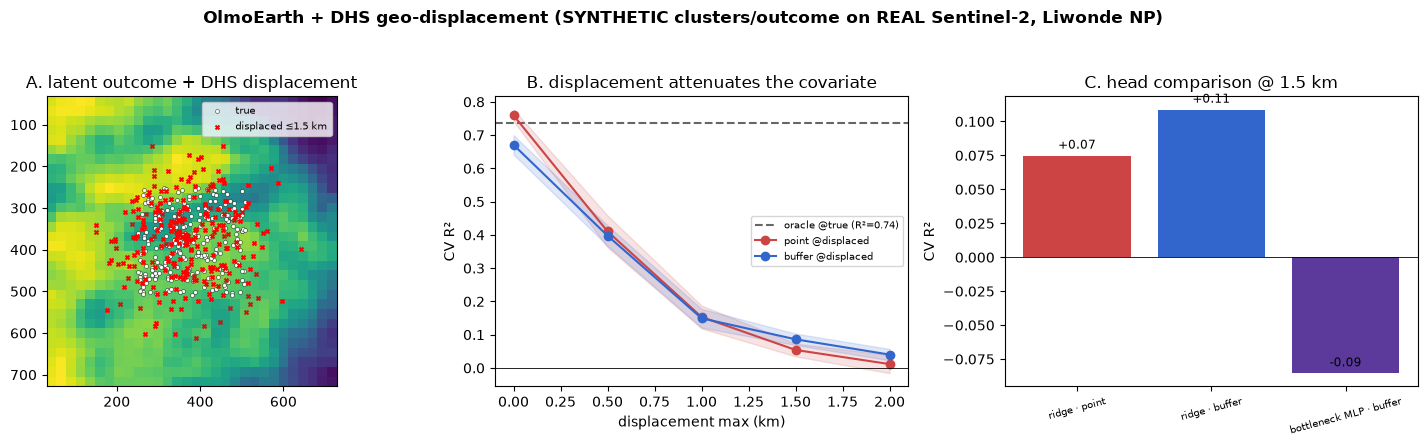

In [6]:
# Compact summary figure for the repo/PR.
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("OlmoEarth + DHS geo-displacement (SYNTHETIC clusters/outcome on REAL Sentinel-2, Liwonde NP)",
             fontsize=12, fontweight="bold")
axs[0].imshow(field, extent=[cols[0], cols[-1], rows[-1], rows[0]], cmap="viridis")
axs[0].scatter(clusters[:,1], clusters[:,0], s=8, c="white", edgecolor="k", linewidth=0.3, label="true")
axs[0].scatter(disp[:,1], disp[:,0], s=8, c="red", marker="x", label=f"displaced ≤{km} km")
axs[0].set_title("A. latent outcome + DHS displacement"); axs[0].legend(fontsize=7.5, loc="upper right")
axs[1].axhline(oracle, ls="--", color="0.4", label=f"oracle @true (R²={oracle:.2f})")
axs[1].plot(REGIMES, pt_mean, "-o", color="#c44", label="point @displaced")
axs[1].fill_between(REGIMES, pt_mean-pt_sd, pt_mean+pt_sd, color="#c44", alpha=0.15)
axs[1].plot(REGIMES, bf_mean, "-o", color="#36c", label="buffer @displaced")
axs[1].fill_between(REGIMES, bf_mean-bf_sd, bf_mean+bf_sd, color="#36c", alpha=0.15)
axs[1].axhline(0, color="k", lw=0.6); axs[1].set_xlabel("displacement max (km)"); axs[1].set_ylabel("CV R²")
axs[1].set_title("B. displacement attenuates the covariate"); axs[1].legend(fontsize=7.5)
axs[2].bar(list(res), list(res.values()), color=["#c44", "#36c", "#5B3A9B"])
axs[2].axhline(0, color="k", lw=0.6); axs[2].set_ylabel("CV R²")
axs[2].set_title(f"C. head comparison @ {km} km")
for i, v in enumerate(res.values()): axs[2].text(i, v+0.005, f"{v:+.2f}", ha="center", fontsize=8.5)
axs[2].set_xticks(range(len(res))); axs[2].set_xticklabels(list(res), rotation=15, fontsize=7.5)
plt.tight_layout(rect=[0,0,1,0.94])
fig.savefig("outputs/dhs_displacement_figure.png", dpi=150, bbox_inches="tight", facecolor="white")
print("saved outputs/dhs_displacement_figure.png")
plt.show()